In [1]:
import ee
import geemap.core as geemap
from datetime import datetime

ee.Authenticate()
ee.Initialize(project='sat-model-1')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


In [52]:
import pandas as pd

In [53]:
start_date = '2021-01-01'
end_date = '2021-06-30'
dt_start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
dt_end_date = datetime.strptime(end_date, '%Y-%m-%d').date()

# etopo1 = ee.Image("NOAA/NGDC/ETOPO1").select('bedrock')

gebco = ee.ImageCollection('projects/sat-io/open-datasets/gebco/gebco_grid').median().select('b1')
        
oisst = ee.ImageCollection("NOAA/CDR/OISST/V2_1") \
    .filterDate(start_date, end_date)
    
oisst_sst = oisst.select('sst')
oisst_ice = oisst.select('ice')

In [54]:
def update_features(fc):
    def enrich(f):
        point = f.geometry()
        date = ee.Date(f.get('date'))
        
        start = date.advance(-3, 'day')
        end = date.advance(3, 'day')
        
        sst = oisst_sst.filterDate(start, end).mean() \
            .sample(point, 5000).first().get('sst')
        
        buffer = point.buffer(1000)
        
        ice = oisst_ice.filterDate(start, end).mean().reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=buffer,
            scale=1855
        ).get('ice')
        depth = gebco.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=buffer,
            scale=500
        ).get('b1')
        return f.set({
            'sst': sst,
            'depth': depth,
            'ice': ice
        })
    return fc.map(enrich)

def update_sst_depth(df, fc):
    fc = update_features(fc)
    results = fc.getInfo()['features']
    id_to_values = {
        f['properties']['id']: (f['properties'].get('sst'),  f['properties'].get('depth'), f['properties'].get('ice'))
        for f in results
    }
    
    df['sst'] = [id_to_values.get(i, 0)[0] * 0.01 for i in df.index]
    df['depth'] = [- id_to_values.get(i, 0)[1] for i in df.index]
    df['ice'] = [id_to_values.get(i, 0)[2] if id_to_values.get(i, 0) else 0 for i in df.index]


In [64]:
all_fish = pd.read_csv('Fish_all.csv', sep=';')

all_fish['formated_date'] = all_fish['datetime'].map(lambda x: datetime.strptime(x, '%d-%b-%Y %H:%M:%S').date())

In [65]:

df = all_fish[(all_fish['formated_date'] >= dt_start_date) & (all_fish['formated_date'] <= dt_end_date)].copy()
features = [
    ee.Feature(
        ee.Geometry.Point([row['lon'], row['lat']]),
        {
            'id': idx,
            'code': row['code'],
            'date': row['formated_date'].strftime('%Y-%m-%d'),
        }
    )
    for idx, row in df.iterrows()
]

fc = ee.FeatureCollection(features)

In [66]:
update_sst_depth(df, fc)
df['relative_depth'] = df['depth'] - df['fishing_depth']

In [ ]:
# Очистка данных
df.loc[df['ice'].isna(), 'ice'] = 0
df.sample(5)

,code,fishing_depth,lon,lat,datetime,sun_angle,formated_date,sst,depth,ice,relative_depth
19491,30107,450,147.80000,55.65000,26-Feb-2021 03:51:00,23.064412,2021-02-26,-1.336667,456,35.666667,6
21119,10256,440,155.61667,49.66667,21-May-2021 17:15:00,-4.669494,2021-05-21,3.601667,435,0.000000,-5
5108,27678,300,148.81667,55.35000,09-Mar-2021 23:36:00,22.146360,2021-03-09,-1.603333,466,70.000000,166
156,30108,420,154.28333,54.71667,17-Jan-2021 10:15:00,-36.998749,2021-01-17,0.751667,393,0.000000,-27
25362,11533,235,154.28333,55.91667,19-Jan-2021 12:45:00,-52.063518,2021-01-19,-0.918333,295,0.000000,60


In [ ]:
# Интересные выловы
interesting = df[(df['relative_depth']>=400)].copy()
interesting.sample(5)

,code,fishing_depth,lon,lat,datetime,sun_angle,formated_date,sst,depth,ice,relative_depth
5066,27678,250,145.65000,55.15000,22-Feb-2021 09:12:00,-14.106960,2021-02-22,-1.416667,836,49.000000,586
3293,13080,250,150.60000,53.95000,18-Mar-2021 00:15:00,30.514835,2021-03-18,0.685000,661,30.833333,411
5072,27678,250,145.66667,55.18333,24-Feb-2021 18:15:00,-26.421321,2021-02-24,-1.405000,684,47.333333,434
21691,10072,200,153.53333,56.20000,28-Mar-2021 02:21:00,36.490945,2021-03-28,-0.615000,857,0.000000,657
25524,11533,500,144.40000,55.50000,12-Apr-2021 15:45:00,-23.346462,2021-04-12,-1.228333,909,37.500000,409


## Аналитика по особенностям вылова

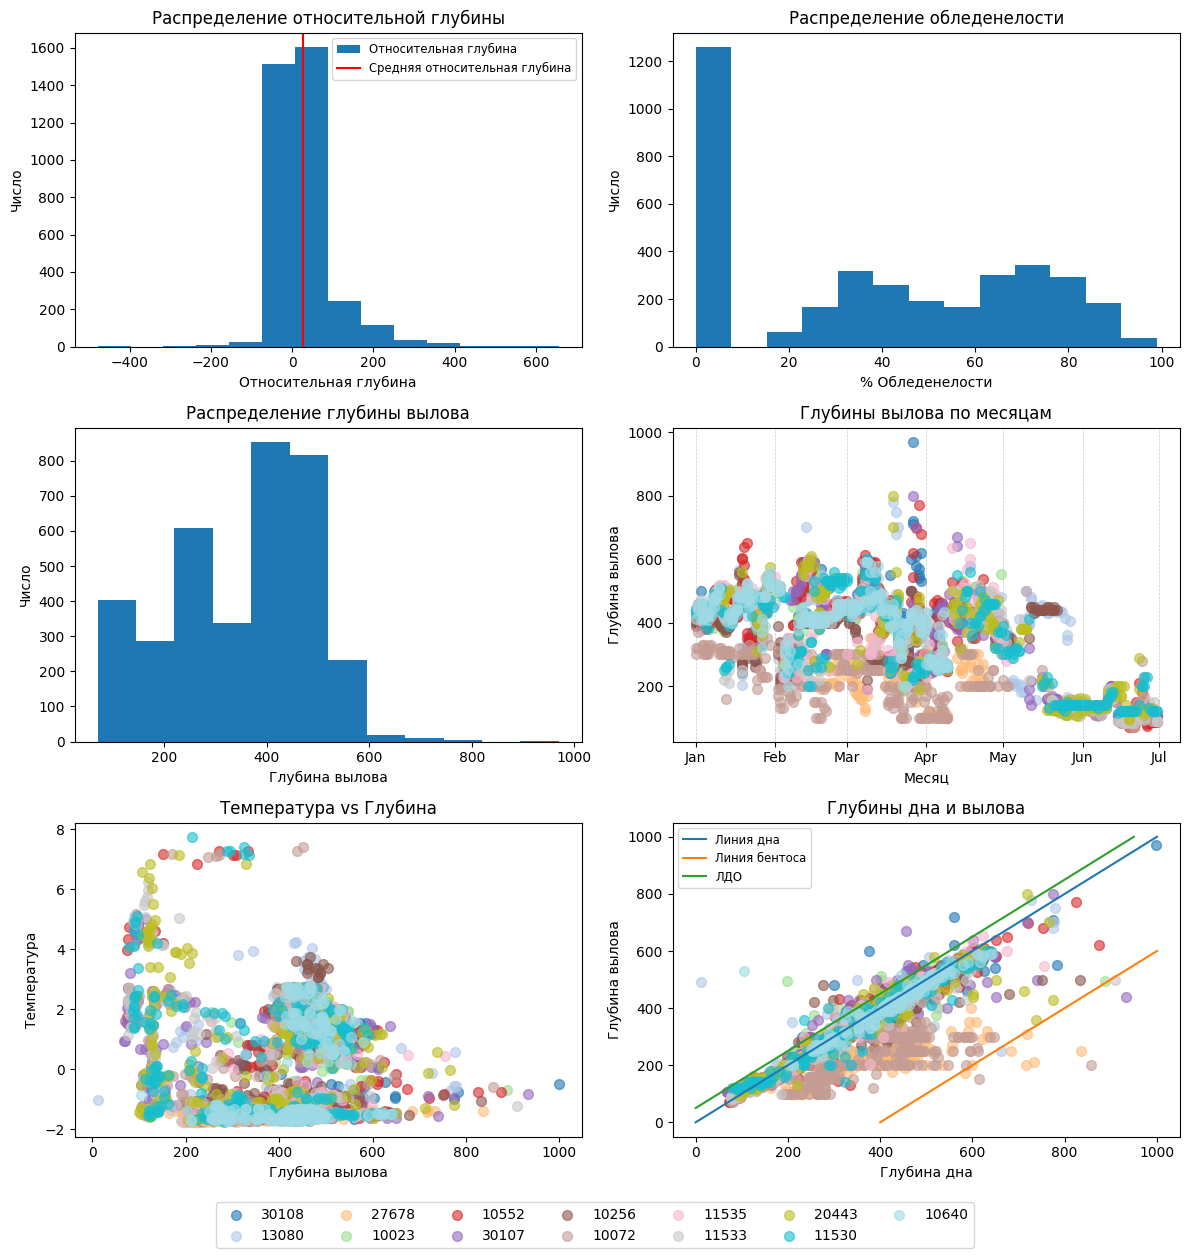

In [71]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
def n_bins(x): # Метод Доана
    return int(1+np.log2(len(x)) + np.log2(1 + np.abs(x.skew())/x.sem())) # int(len(x)**0.5) + 1


unique_codes = df['code'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_codes)))
color_dict = dict(zip(unique_codes, colors))

fig, ((ax1, ax2),(ax3, ax4),(ax5, ax6)) = plt.subplots(3, 2, figsize=(12, 12))
ax1.hist(df['relative_depth'], bins=n_bins(df['relative_depth']), label='Относительная глубина')
ax1.axvline(df['relative_depth'].mean(), color='r', label='Средняя относительная глубина')
ax1.set_title('Распределение относительной глубины')
ax1.set_xlabel('Относительная глубина')
ax1.set_ylabel('Число')
ax1.legend(loc='upper right', fontsize='small')

ax2.hist(df['ice'], bins=n_bins(df[~df['ice'].isna()]['ice']))
ax2.set_title('Распределение обледенелости')
ax2.set_xlabel('% Обледенелости')
ax2.set_ylabel('Число')

ax3.hist(df['fishing_depth'], bins=n_bins(df['fishing_depth']), label='Fishing depth')
ax3.set_title('Распределение глубины вылова')
ax3.set_xlabel('Глубина вылова')
ax3.set_ylabel('Число')

handles, labels = [], []
for code, color in zip(unique_codes, colors):
    mask = df['code'] == code
    scatter = ax6.scatter(df.loc[mask, 'depth'], df.loc[mask, 'fishing_depth'], 
               c=[color], s=50, alpha=0.6)
    ax5.scatter(df.loc[mask, 'depth'], df.loc[mask, 'sst'], 
               c=[color], s=50, alpha=0.6)
    ax4.scatter(df.loc[mask,'formated_date'], df.loc[mask,'fishing_depth'],
                c=[color], s=50, alpha=0.6)
    
    handles.append(scatter)
    labels.append(f'{code}')
    
ax4.set_title('Глубины вылова по месяцам')
ax4.set_xlabel('Месяц')
ax4.set_ylabel('Глубина вылова')
months = [dt_start_date + pd.DateOffset(months=i) for i in range(0, 7)]
ax4.set_xticks(months, [m.strftime('%b') for m in months], minor=False)
ax4.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)


ax6.plot([0, 1000], [0, 1000], label='Линия дна')
ax6.plot([400, 1000], [0, 600], label='Линия бентоса')
ax6.plot([0, 950], [50, 1000], label='ЛДО') # Линия допустимой ошибки
ax6.legend(loc='upper left', fontsize='small')
ax6.set_title('Глубины дна и вылова')
ax6.set_xlabel('Глубина дна')
ax6.set_ylabel('Глубина вылова')
    
ax5.set_xlabel('Глубина вылова')
ax5.set_ylabel('Температура')
ax5.set_title('Температура vs Глубина')

fig.legend(handles=handles, labels=labels, 
           loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=(len(unique_codes)+1)//2)


plt.tight_layout()
plt.show();

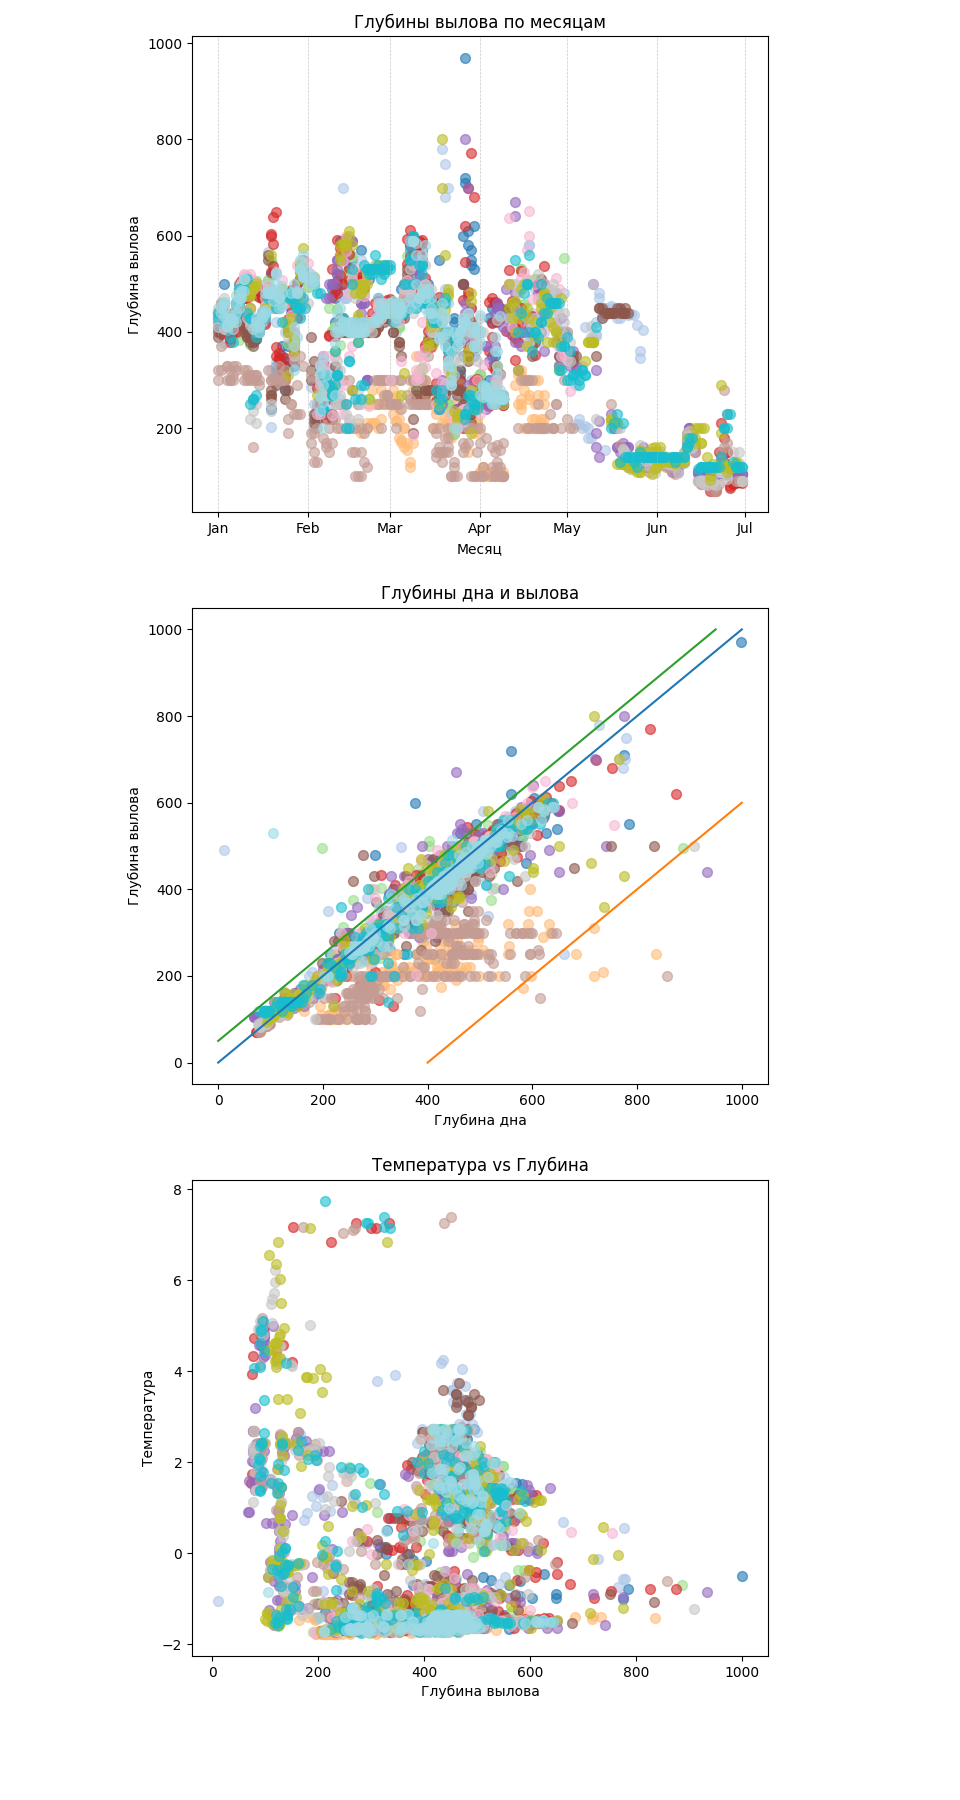

In [11]:
%matplotlib widget
from ipywidgets import Button, VBox, Layout, HBox, Label, Checkbox
from IPython.display import display

fig, ((ax1),(ax2),(ax3)) = plt.subplots(3, 1, figsize=(12*8/10, 18))


def update_plots(selected_codes):
    """Обновляет графики на основе выбранных кодов"""
    for ax in [ax1, ax2, ax3]:
        ax.clear()
    
    for code in selected_codes:
        mask = df['code'] == code
        color = color_dict[code]
        
        ax1.scatter(df.loc[mask, 'formated_date'], 
                   df.loc[mask, 'fishing_depth'],
                   c=[color], s=50, alpha=0.6)
        ax2.scatter(df.loc[mask, 'depth'], 
                   df.loc[mask, 'fishing_depth'], 
                   c=[color], s=50, alpha=0.6)
        ax3.scatter(df.loc[mask, 'depth'], 
                   df.loc[mask, 'sst'], 
                   c=[color], s=50, alpha=0.6)
        
    
    # Восстанавливаем настройки осей
    ax1.set_title('Глубины вылова по месяцам')
    ax1.set_xlabel('Месяц')
    ax1.set_ylabel('Глубина вылова')
    ax1.set_xticks(months, [m.strftime('%b') for m in months], minor=False)
    ax1.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax2.set_title('Глубины дна и вылова')
    ax2.set_xlabel('Глубина дна')
    ax2.set_ylabel('Глубина вылова')
    
    ax2.plot([0, 1000], [0, 1000], label='Линия дна')
    ax2.plot([400, 1000], [0, 600], label='Линия бентоса')
    ax2.plot([0, 950], [50, 1000], label='ЛДО') # Линия допустимой ошибки
    
    ax3.set_title('Температура vs Глубина')
    ax3.set_xlabel('Глубина вылова')
    ax3.set_ylabel('Температура')
    
    fig.canvas.draw_idle()

plt.subplots_adjust(left=0.2, right=0.8, top=0.98, bottom=0.08, 
                    wspace=0, hspace=0.2)

checkboxes = {}
for code in unique_codes:
    cb = Checkbox(
        value=True,
        layout=Layout(width='50px'),
        indent = False
    )
    checkboxes[code] = VBox([Label(f'{code}'), cb], layout=Layout(
        align_items='center'
    ))

# Функция обновления
def update_from_checkboxes(change):
    selected = [code for code, cb in checkboxes.items() if cb.children[1].value]
    update_plots(selected)

# Привязываем обработчики
for cb in checkboxes.values():
    cb.children[1].observe(update_from_checkboxes, names='value')


# Располагаем всё горизонтально
checkbox_row = HBox(list(checkboxes.values()), layout=Layout(justify_content='center', flex_wrap='wrap'))

controls = VBox([
    checkbox_row
])

display(checkbox_row)

update_plots(unique_codes)
fig.canvas.toolbar_visible = False
fig.suptitle('')
plt.show();

In [87]:
def hsl_to_hex(h, s, l):
    """Convert HSL to hex color."""
    import colorsys
    r, g, b = colorsys.hls_to_rgb(h/360, l/100, s/100)
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

def get_distributed_colors(n, dev=360):
    """Generate n visually distinct colors."""
    colors = []
    for i in range(n):
        hue = (i * dev / n) % dev
        colors.append(hsl_to_hex(hue, 70, 50))
    return colors

In [90]:
def layer_point(m, ebsRegion):
    unique_codes = list(range(6))# df['code'].unique().tolist()
    color_map = get_distributed_colors(len(unique_codes), 90)

    ee_colors = ee.Dictionary({str(k): v for k, v in zip(unique_codes, color_map)})

    def styled_f(f):
        code_str = ee.Number(f.get('code')).format('%d')
        month = ee.Date(f.get('date')).get('month')
        color = ee_colors.get(month)
        
        return f.set({
            'style': {
                'color': color,
                'pointSize': 8,
                'pointShape': 'circle'
            }
        })

    fc_styled = fc.map(styled_f)

    m.addLayer(fc_styled.style(styleProperty='style'), {}, 'Points')

def layer_depth(m, ebsRegion):
    vis_params = {
        'min': -1400,
        'max': 0,
        'palette': ['#000004', '#420a68', '#932667', '#dd513a', '#fca50a', '#fcffa4'] # ['#081d58', '#253494', '#225ea8', '#1d91c0', '#41b6c4', '#7fcdbb', '#c7e9b4']
    }
        
    m.add_layer(gebco.clip(ebsRegion), vis_params, 'Глубина (Gebco)', opacity=0.6)

def layer_temperature(m, ebsRegion):
    visParams = {
        'min': -180.0,
        'max': 500.0,
        'palette': [
            '040274', '040281', '0502a3', '0502b8', '0502ce', '0502e6',
            '0602ff', '235cb1', '307ef3', '269db1', '30c8e2', '32d3ef',
            '3be285', '3ff38f', '86e26f', '3ae237', 'b5e22e', 'd6e21f',
            'fff705', 'ffd611', 'ffb613', 'ff8b13', 'ff6e08', 'ff500d',
            'ff0000', 'de0101', 'c21301', 'a71001', '911003'
        ],
    }

    m.add_layer(oisst_sst.mean().clip(ebsRegion), visParams, 'Темература', opacity=0.6)

def layer_ice(m, ebsRegion):
    ice_concentration_vis = {
        'min': 0,
        'max': 100,
        'palette': [
            '#ffffff',  # 0% - open water (white)
            '#c6e9ff',  # 10% - very light blue
            '#9ed6ff',  # 20% - light blue
            '#6bc5ff',  # 30% - light-medium blue
            '#3cb0ff',  # 40% - medium blue
            '#1e8fcf',  # 50% - medium-dark blue
            '#0c6b9e',  # 60% - dark blue
            '#054c6e',  # 70% - darker blue
            '#023246',  # 80% - very dark blue
            '#011e2b',  # 90% - almost black-blue
            '#000000'   # 100% - full ice cover (black)
        ]
    }

    m.add_layer(oisst_ice.mean().clip(ebsRegion), ice_concentration_vis, 'Лед', opacity=0.6)

In [91]:
m = geemap.Map()
padding = 2
ebsRegion = ee.Geometry.Rectangle((df['lon']+360).mod(360).min()-padding, df['lat'].min()-padding,
                                  (df['lon']+360).mod(360).max()+padding, df['lat'].max()+padding)

layer_depth(m, ebsRegion)
layer_ice(m, ebsRegion)
layer_temperature(m, ebsRegion)
layer_point(m, ebsRegion)

m.add("inspector")
m.centerObject(ebsRegion) 
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [15]:
# Сохраняем результат измерений
df.to_csv('result.csv')

In [34]:
mtsat = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI') \
    .filterDate('2021-01-01', '2021-02-01') \
    .select('sst')

visParams = {
    'min': -6,
    'max': 15,
    'palette': [
        '040274', '040281', '0502a3', '0502b8', '0502ce', '0502e6',
        '0602ff', '235cb1', '307ef3', '269db1', '30c8e2', '32d3ef',
        '3be285', '3ff38f', '86e26f', '3ae237', 'b5e22e', 'd6e21f',
        'fff705', 'ffd611', 'ffb613', 'ff8b13', 'ff6e08', 'ff500d',
        'ff0000', 'de0101', 'c21301', 'a71001', '911003'
    ],
}

m.add_layer(mtsat.mean(), visParams, 'Темература L3SMI', opacity=0.6)